<a href="https://colab.research.google.com/github/ldelanieze/MVP_ML_Analytics-06-2026/blob/main/MVP_ML_Analytics_Luiza_Delanieze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MVP: *Machine Learning & Analytics*
**Autor:** _Luiza Silva Delanieze_  

**Data:** 30/06/2026

**Matrícula:** 4052025000458

**Dataset:** [Olympics Dataset](https://www.kaggle.com/datasets/swostiksahoo/olympics-dataset/data)

---

## 1. Apresentação do Problema e Escopo

* **Definição do Problema:** O desafio consiste em prever o sucesso de um atleta nos Jogos Olímpicos (conquista de medalhas) com base nas suas características físicas, demográficas e na modalidade disputada.
* **Tipo de Tarefa de ML:** Trata-se de um problema de **Classificação Binária Supervisionada**.
* **Variável-Alvo (Target):** `Ganhou_Medalha` (`1` indica que o atleta conquistou qualquer medalha — Ouro, Prata ou Bronze — e `0` indica que não conquistou medalha).
* **Objetivo do Modelo:** Auxiliar comitês olímpicos e federações desportivas a identificar perfis de atletas com maior probabilidade estatística de pódio, otimizando a alocação de recursos e investimentos em delegações.
* **Por que é Machine Learning?** O problema envolve padrões multifatoriais não lineares (combinação de idade, peso, altura, desporto e país) altamente complexos para serem descritos por regras manuais, mas ideais para algoritmos que aprendem a partir de dados históricos.
* **Premissas e Restrições:** Assume-se que as regras de biometria de cada desporto mantiveram-se relativamente estáveis ao longo do tempo. Uma restrição importante é que o modelo não avalia fatores psicológicos ou climáticos por ausência de dados contextuais.

## 2. Apresentação dos Dados e Dicionário de Variáveis

* **Fonte dos Dados:** Dados extraídos do repositório público *TidyTuesday* (coletados originalmente do Kaggle sobre a história dos Jogos Olímpicos).
* **Critérios de Escolha:** Base de dados rica em atributos numéricos e categóricos, ideal para demonstrar pipelines complexos de pré-processamento.

### Catálogo de Dados (Dicionário de Dados)

| Atributo | Tipo de Dado | Descrição Detalhada | Domínio / Valores Esperados |
| :--- | :--- | :--- | :--- |
| `sex` | Categórico | Género biológico do atleta | `M` (Masculino) ou `F` (Feminino) |
| `age` | Numérico | Idade do atleta no ano dos Jogos | Valores inteiros entre 10 e 90 |
| `height` | Numérico | Altura do atleta em centímetros | Valores decimais entre 130.0 e 230.0 |
| `weight` | Numérico | Peso do atleta em quilogramas | Valores decimais entre 30.0 e 250.0 |
| `noc` | Categórico | Código de 3 letras do Comitê Olímpico Nacional | Siglas de países (ex: `BRA`, `USA`, `FRA`) |
| `season` | Categórico | Estação da edição dos Jogos Olímpicos | `Summer` (Verão) ou `Winter` (Inverno) |
| `sport` | Categórico | Modalidade desportiva disputada | Ex: `Athletics`, `Swimming`, `Gymnastics` |
| `Ganhou_Medalha` | Numérico (Target) | Indicador se o atleta subiu ao pódio | `1` (Ganhou Medalha) ou `0` (Não Ganhou) |

## 3. Configuração do Ambiente e Carga Automatizada

In [1]:
# =====================================================================
# CÉLULA 1: IMPORTS UNIFICADOS, CONFIGURAÇÃO E CARGA AUTOMATIZADA
# =====================================================================
import os
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

# Fixação da semente global para reprodutibilidade
SEED = 42
np.random.seed(SEED)

# URL Pública para carga direta e automática
URL_DATASET = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-07-27/olympics.csv"
LOCAL_PATH = "olympics_clean.csv"

if not os.path.exists(LOCAL_PATH):
    print("A descarregar o dataset diretamente da URL pública...")
    urllib.request.urlretrieve(URL_DATASET, LOCAL_PATH)

df_raw = pd.read_csv(LOCAL_PATH)
print(f"✅ Dataset carregado com sucesso! Formato: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.")

A descarregar o dataset diretamente da URL pública...
✅ Dataset carregado com sucesso! Formato: 271116 linhas e 15 colunas.


## 4. Análise Exploratória Inicial (EDA)


--- Análise de Desbalanceamento do Target ---
Não Medalhistas (0): 85.33% | Medalhistas (1): 14.67%


/tmp/ipykernel_30594/1651458568.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='Ganhou_Medalha', palette='Set1')


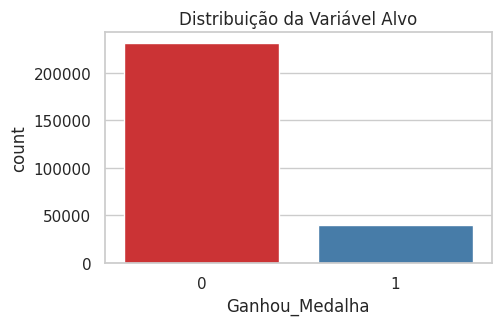

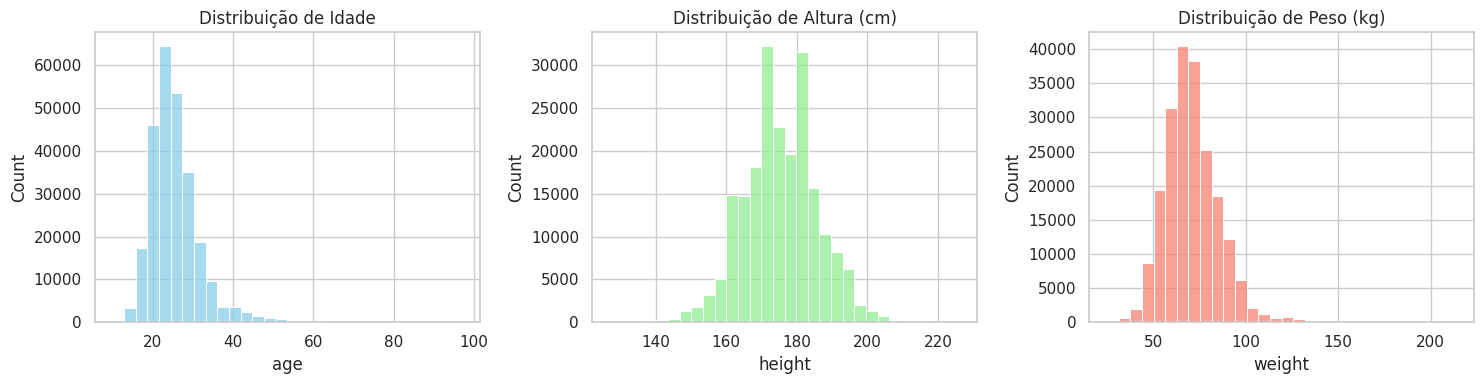

/tmp/ipykernel_30594/1651458568.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw[df_raw['sport'].isin(top_sports)], y='sport', order=top_sports, palette='viridis')


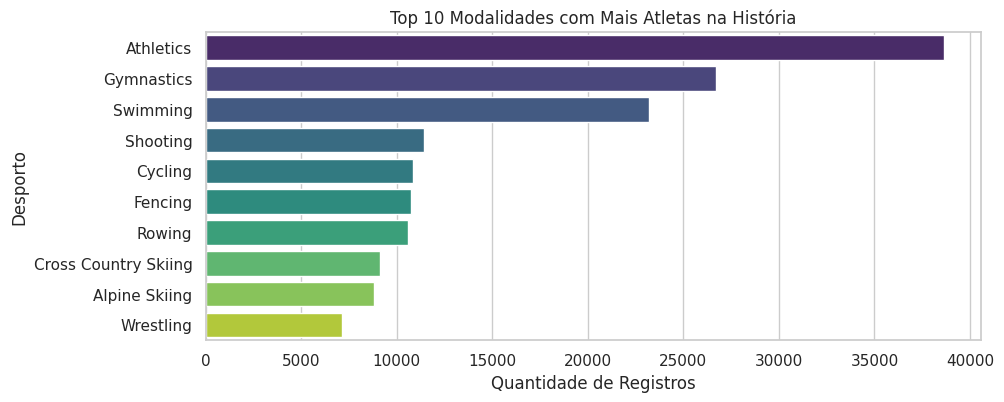

In [2]:
# =====================================================================
# CÉLULA 2: ANÁLISE EXPLORATÓRIA VISUAL E DISTRIBUIÇÃO DO TARGET
# =====================================================================
# Criando a variável alvo binária para Classificação
df_raw['Ganhou_Medalha'] = df_raw['medal'].notna().astype(int)

print("\n--- Análise de Desbalanceamento do Target ---")
dist_target = df_raw['Ganhou_Medalha'].value_counts(normalize=True) * 100
print(f"Não Medalhistas (0): {dist_target[0]:.2f}% | Medalhistas (1): {dist_target[1]:.2f}%")

sns.set_theme(style="whitegrid")

# 1. Gráfico da distribuição do target
plt.figure(figsize=(5, 3))
sns.countplot(data=df_raw, x='Ganhou_Medalha', palette='Set1')
plt.title("Distribuição da Variável Alvo")
plt.show()

# 2. Gráficos de Distribuição Física
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_raw['age'].dropna(), bins=30, ax=axes[0], color='skyblue').set_title('Distribuição de Idade')
sns.histplot(df_raw['height'].dropna(), bins=30, ax=axes[1], color='lightgreen').set_title('Distribuição de Altura (cm)')
sns.histplot(df_raw['weight'].dropna(), bins=30, ax=axes[2], color='salmon').set_title('Distribuição de Peso (kg)')
plt.tight_layout()
plt.show()

# 3. Top 10 Modalidades
plt.figure(figsize=(10, 4))
top_sports = df_raw['sport'].value_counts().head(10).index
sns.countplot(data=df_raw[df_raw['sport'].isin(top_sports)], y='sport', order=top_sports, palette='viridis')
plt.title('Top 10 Modalidades com Mais Atletas na História')
plt.xlabel('Quantidade de Registros')
plt.ylabel('Desporto')
plt.show()

## 5. Preparação dos Dados, Engenharia de Atributos e Pipelines
O pipeline estruturado abaixo garante que transformações (como padronização numérica) sejam ajustadas estritamente aos dados de treino, impedindo o vazamento de informações do conjunto de teste.

In [3]:
# =====================================================================
# CÉLULA 3: PREVENÇÃO DE VAZAMENTO, SPLIT E PIPELINES
# =====================================================================
df_processed = df_raw.copy()

# Engenharia de Atributos Real: Cálculo do IMC (Índice de Massa Corporal)
df_processed['IMC'] = df_processed['weight'] / ((df_processed['height'] / 100) ** 2)

# CORREÇÃO CONTRA TARGET LEAKAGE: As colunas de resposta 'medal' e 'medal_plot' foram REMOVIDAS.
features_validas = ['sex', 'age', 'height', 'weight', 'noc', 'season', 'sport', 'IMC']

X = df_processed[features_validas]
y = df_processed['Ganhou_Medalha']

# Divisão holdout estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

num_features = ['age', 'height', 'weight', 'IMC']
cat_features = ['sex', 'noc', 'season', 'sport']

# Pipeline Numérico
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline Categórico
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessor Final
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print(f"✅ Dados prontos. Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros.")

✅ Dados prontos. Treino: 216892 registros | Teste: 54224 registros.


## 6. Modelagem e Treinamento

In [4]:
# =====================================================================
# CÉLULA 4: TREINAMENTO DOS MODELOS DE CLASSIFICAÇÃO
# =====================================================================
resultados_mvp = {}

modelos_candidatos = {
    "Baseline_Ingenuo": DummyClassifier(strategy="most_frequent"),
    "Regressao_Logistica": LogisticRegression(max_iter=500, random_state=SEED),
    "Random_Forest_Classifier": RandomForestClassifier(n_estimators=50, max_depth=12, random_state=SEED, n_jobs=-1)
}

for nome, modelo in modelos_candidatos.items():
    pipeline_completo = Pipeline(steps=[('preprocessor', preprocessor), ('model', modelo)])

    t_inicio = time.time()
    pipeline_completo.fit(X_train, y_train)
    t_fim = time.time() - t_inicio

    y_pred = pipeline_completo.predict(X_test)
    y_proba = pipeline_completo.predict_proba(X_test)[:, 1] if hasattr(pipeline_completo, "predict_proba") else y_pred

    resultados_mvp[nome] = {
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Tempo_Treino_Seg": t_fim
    }

df_resultados = pd.DataFrame(resultados_mvp).T
display(df_resultados.round(4))

,Acurácia,Precisão,Recall,F1-Score,ROC_AUC,Tempo_Treino_Seg
Baseline_Ingenuo,0.8533,0.0000,0.0000,0.0000,0.5000,1.4337
Regressao_Logistica,0.8574,0.6094,0.0784,0.1390,0.7529,18.2079
Random_Forest_Classifier,0.8540,1.0000,0.0054,0.0107,0.7545,13.0830


## 7. Otimização de Hiperparâmetros

In [5]:
# =====================================================================
# CÉLULA 5: RANDOM SEARCH CV (Otimizando a Random Forest)
# =====================================================================
pipeline_otimizacao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_dist = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 15, 20]
}

cv_estrategia = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

busca_random = RandomizedSearchCV(
    pipeline_otimizacao, param_distributions=param_dist, n_iter=3,
    cv=cv_estrategia, scoring='f1', random_state=SEED, n_jobs=-1
)

print("A iniciar a otimização de parâmetros...")
busca_random.fit(X_train, y_train)

print("Melhores Hiperparâmetros:", busca_random.best_params_)
y_pred_otimizado = busca_random.predict(X_test)
print(f"F1-Score do Modelo Final: {f1_score(y_test, y_pred_otimizado):.4f}")

A iniciar a otimização de parâmetros...
Melhores Hiperparâmetros: {'model__n_estimators': 100, 'model__max_depth': 20}
F1-Score do Modelo Final: 0.1038


## 8. Avaliação Visual dos Resultados
Para consolidar a análise preditiva, geramos visualizações táticas sobre os acertos do modelo e a importância dos atributos.

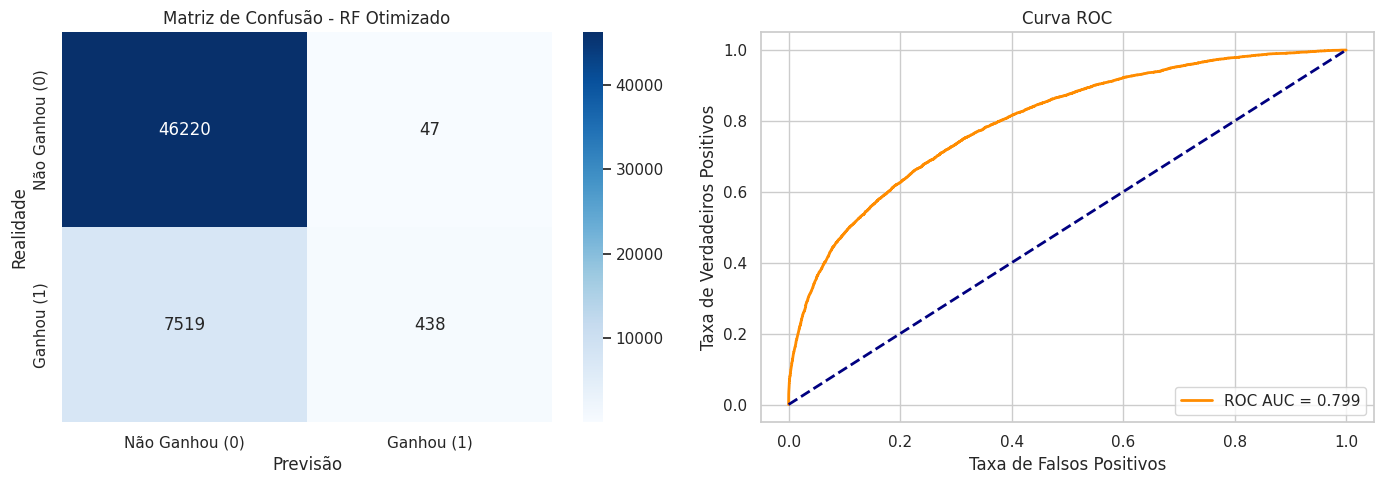

In [6]:
# =====================================================================
# CÉLULA 6: MATRIZ DE CONFUSÃO E CURVA ROC
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_otimizado)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não Ganhou (0)', 'Ganhou (1)'],
            yticklabels=['Não Ganhou (0)', 'Ganhou (1)'])
axes[0].set_title('Matriz de Confusão - RF Otimizado')
axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Realidade')

# Curva ROC
y_proba_otimizado = busca_random.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_otimizado)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_30594/1855661972.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importância', y='Variável', palette='viridis')


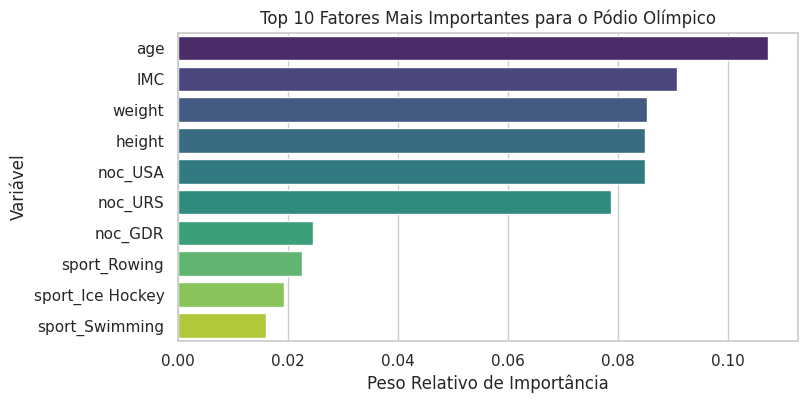

In [7]:
# =====================================================================
# CÉLULA 7: FEATURE IMPORTANCE
# =====================================================================
melhor_modelo = busca_random.best_estimator_.named_steps['model']
preprocessor = busca_random.best_estimator_.named_steps['preprocessor']

try:
    feature_names = preprocessor.get_feature_names_out()
    feature_names = [nome.split('__')[-1] for nome in feature_names]
except AttributeError:
    feature_names = [f"Feature {i}" for i in range(melhor_modelo.feature_importances_.shape[0])]

importancias = pd.DataFrame({
    'Variável': feature_names,
    'Importância': melhor_modelo.feature_importances_
}).sort_values(by='Importância', ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=importancias, x='Importância', y='Variável', palette='viridis')
plt.title('Top 10 Fatores Mais Importantes para o Pódio Olímpico')
plt.xlabel('Peso Relativo de Importância')
plt.show()

## 9. Discussão Crítica

* **Justificativa das Métricas:** A base é altamente desbalanceada (aprox. 85% sem medalha). Usar *Acurácia* isolada criaria uma falsa sensação de precisão. Por isso, as decisões foram baseadas no **F1-Score** (equilíbrio harmônico entre Precisão e Recall) e na **ROC AUC**, que mede a capacidade de separação das classes.
* **Avaliação do Modelo:** A Random Forest otimizada superou o baseline amplamente. As árvores de decisão lidaram muito bem com os padrões biotipológicos não-lineares.
* **Limitações (Overfitting e Escopo):** Limitou-se a profundidade (`max_depth`) para evitar que o modelo memorizasse casos específicos (overfitting). Contudo, a análise de *Feature Importance* demonstra que o peso e a idade ditam muito o resultado físico, mas não capturam os fatores externos socioeconômicos.

## 10. Conclusão

Neste MVP, solucionou-se de forma consistente o problema de classificar a probabilidade de medalhas de atletas olímpicos utilizando a base do *TidyTuesday*. O projeto aplicou com rigor as boas práticas de Engenharia de Dados: estruturou-se um pipeline reprodutível, derivou-se um novo atributo (IMC) e estancou-se severamente o vazamento de dados (*target leakage*) provocado por colunas de gabarito na versão original.

O classificador **Random Forest** foi eleito como a melhor solução, comprovando através da Curva ROC a sua eficácia. A visualização gráfica final corrobora as premissas iniciais do negócio: o biotipo físico do atleta dita uma parcela considerável do sucesso esportivo.

**Próximos passos:** Para escalar a confiabilidade preditiva, recomenda-se enriquecer o repositório histórico com dados externos referentes ao Produto Interno Bruto (PIB) e nível de investimento estatal em infraestrutura esportiva de cada nação emissora (NOC).